In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppresses most TF warnings/errors

import tensorflow as tf
# Explicitly allow memory growth to prevent "factory" registration crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesResampler,TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans
from tslearn.shapelets import LearningShapelets, grabocka_params_to_shapelet_size_dict
import stumpy # Per Motif e Anomalies
import librosa.effects
from tslearn.utils import to_time_series_dataset
from tqdm.notebook import tqdm

In [4]:
# 1. Carica la matrice (veloce)
X = np.load("processed_audio_data/X_features_one_minute_padded.npy")

indices_to_keep = np.r_[0:13, 20:33]
X = X[:, :, indices_to_keep]


df_processed = pd.read_csv('processed_audio_data/df_processed_1_minute.csv')
# 2. Prendi y_ok direttamente dal tuo df_processed (risolve il NameError)
y_ok = df_processed['id_artist'].values

print(f"Dati pronti! X shape: {X.shape}, y_ok: {len(y_ok)}")

Dati pronti! X shape: (443, 646, 26), y_ok: 443


In [5]:
AUDIO_COLS = [
    # Audio/Acoustic Features (Using a representative sample)
    'bpm', 'centroid', 'flux', 'rms', 'spectral_complexity', 'pitch', 'flatness', 'duration_ms'
]

In [6]:
scaler = TimeSeriesScalerMeanVariance(mu=0, std=1)
X_scaled = scaler.fit_transform(X)

In [7]:
# 1. Define your mapping (Who is 0 and who is 1?)
# Make sure the strings match exactly what is in your dataframe (check for lowercase)
artist_mapping = {
    'fedez': 0,
    'fabri fibra': 1
}

# 2. Create the labels
# We iterate through the dataframe to ensure the order matches X_final exactly
y_true = []

print("🏷️ Generating labels from 'name_artist'...")

for artist in df_processed['name_artist']:
    # Convert to lowercase to be safe
    clean_name = str(artist).lower().strip()

    if clean_name in artist_mapping:
        y_true.append(artist_mapping[clean_name])
    else:
        # Fallback if there's a typo or different name (e.g. "Fedez feat...")
        # You might want to print these to check
        if 'fedez' in clean_name:
            y_true.append(0)
        elif 'fibra' in clean_name:
            y_true.append(1)
        else:
            print(f"⚠️ Warning: Unknown artist '{artist}' found. Assigning -1.")
            y_true.append(-1)

# 3. Convert to Numpy Array
y_true = np.array(y_true)

# 4. Verification
print(f"✅ y_true created! Shape: {y_true.shape}")
print(f"   Count for Fedez (0): {np.sum(y_true == 0)}")
print(f"   Count for Fibra (1): {np.sum(y_true == 1)}")

# Check if X_final and y_true match in length
if 'X_final' in locals() and len(X) != len(y_true):
    print(f"❌ ERROR: Mismatch! X has {len(X)} items, but y_true has {len(y_true)}.")
else:
    print("✅ Lengths match perfectly with X.")

X_shape = to_time_series_dataset(X)
y_shape = y_true # 0 per Fedez, 1 per Fibra


🏷️ Generating labels from 'name_artist'...
✅ y_true created! Shape: (443,)
   Count for Fedez (0): 175
   Count for Fibra (1): 268
✅ Lengths match perfectly with X.


In [8]:
# 1. Verifica e Scaling
# X_final shape: (448, 2584, 13)
# Il modello LearningShapelets beneficia enormemente dallo scaling MinMax (0, 1)
X_scaled_ls = TimeSeriesScalerMinMax().fit_transform(X)
X_scaled_ls = X_scaled_ls.astype('float32')

# 2. Estrazione dimensioni corrette
n_ts, ts_sz, n_features = X_scaled_ls.shape
n_classes = len(np.unique(y_true)) # Assicurati che y sia definito (es. i tuoi generi)

# 3. Calcolo parametri di Grabocka
# Nota: l=0.1 significa che la shapelet sarà lunga il 10% di 2584 (~258 punti)
# r=1 significa che usiamo una sola scala di lunghezza.
shapelet_sizes = grabocka_params_to_shapelet_size_dict(
    n_ts=n_ts,
    ts_sz=ts_sz,
    n_classes=n_classes,
    l=0.02,
    r=1
)

print(f"Dimensioni: {n_ts} tracce, {ts_sz} sample, {n_features} feature")
print(f"Classi rilevate: {n_classes}")
print(f"Shapelet pianificate: {shapelet_sizes}")

Dimensioni: 443 tracce, 646 sample, 26 feature
Classi rilevate: 2
Shapelet pianificate: {12: 5}


In [9]:
import time
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tslearn.shapelets import LearningShapelets

# 1. Split Data
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_ls, y_true, test_size=0.2, random_state=42, stratify=y_true
)


In [ ]:

# 2. Configure Model
custom_lr = 0.003
custom_optimizer = Adam(learning_rate=custom_lr)

shp_clf = LearningShapelets(
    n_shapelets_per_size=shapelet_sizes,
    optimizer=custom_optimizer,
    batch_size=8,
    weight_regularizer=0.1,
    max_iter=1,               # Only 1 iter needed for init
    random_state=42,
    verbose=1,
    scale=False
)

# 3. FAST Initialization (The Trick)
# We fit on a tiny slice (30 samples) just to build the internal layers and shapelets quickly.
print("🚀 Initializing model on subset (fast)...")
shp_clf.fit(X_train[:30], y_train[:30])
print("✅ Initialization complete. Model is built.")

🚀 Initializing model on subset (fast)...


/usr/local/lib/python3.12/dist-packages/tslearn/shapelets/shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 458ms/step - binary_accuracy: 0.6575 - binary_crossentropy: 0.6679 - loss: 0.8887
✅ Initialization complete. Model is built.


In [11]:
# 1. Prepare Data for Keras
y_train_reshaped = y_train.reshape(-1, 1)
y_val_reshaped = y_val.reshape(-1, 1)

# 2. Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 3. Start Full Training
print(" Starting full Keras training...")
start_time = time.time()

history = shp_clf.model_.fit(
    X_train,
    y_train_reshaped,
    epochs=200,
    batch_size=8,
    validation_data=(X_val, y_val_reshaped),
    callbacks=[early_stop],
    verbose=1
)

# 4. Show Duration
duration = time.time() - start_time
print(f"⏱️ Training finished in {duration:.1f} seconds.")

 Starting full Keras training...
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - binary_accuracy: 0.5939 - binary_crossentropy: 0.6721 - loss: 0.8723 - val_binary_accuracy: 0.6067 - val_binary_crossentropy: 0.6583 - val_loss: 0.8163
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.6059 - binary_crossentropy: 0.6648 - loss: 0.8117 - val_binary_accuracy: 0.6067 - val_binary_crossentropy: 0.6555 - val_loss: 0.7724
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6015 - binary_crossentropy: 0.6615 - loss: 0.7703 - val_binary_accuracy: 0.6067 - val_binary_crossentropy: 0.6532 - val_loss: 0.7401
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6015 - binary_crossentropy: 0.6592 - loss: 0.7401 - val_binary_accuracy: 0.6067 - val_binary_crossentropy: 0.6515 - val_loss: 0.7162
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6015 - binary_crossentropy: 0.6572 - loss: 0.7177 - val_binary_accuracy: 0

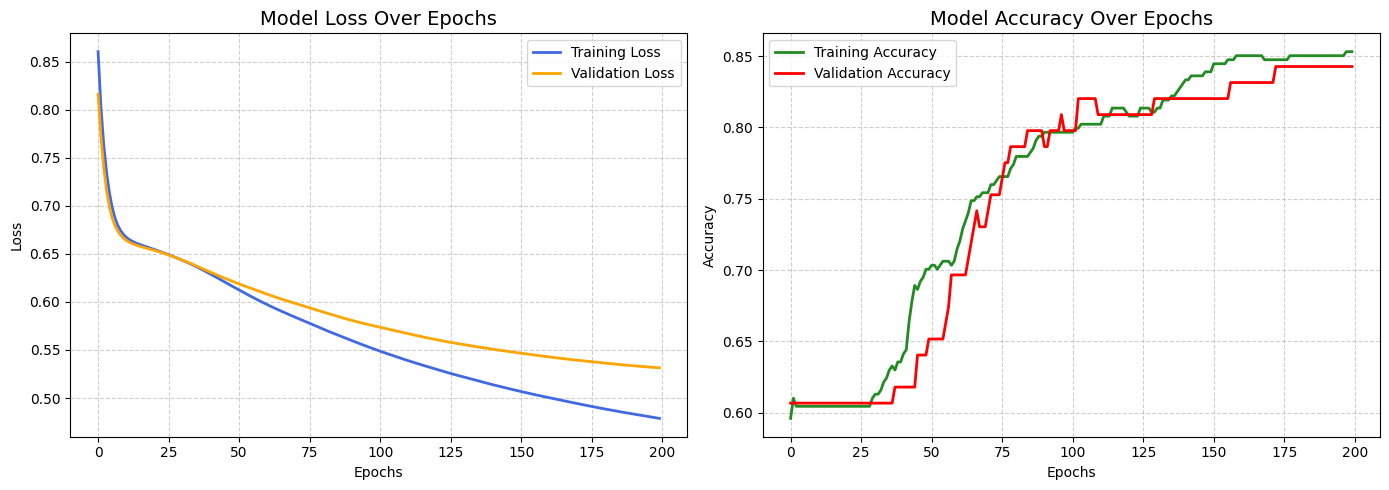

In [12]:
import matplotlib.pyplot as plt

# 1. Access the history dictionary
# tslearn stores the history in the .model_ attribute (which is the underlying Keras model)
history = shp_clf.model_.history.history

# 2. Create the plots
plt.figure(figsize=(14, 5))

# --- Plot Loss ---
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss', color='royalblue', linewidth=2)
if 'val_loss' in history:
    plt.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot Accuracy ---
plt.subplot(1, 2, 2)
# Note: depending on your version, key might be 'accuracy' or 'binary_accuracy'
acc_key = 'accuracy' if 'accuracy' in history else 'binary_accuracy'
plt.plot(history[acc_key], label='Training Accuracy', color='forestgreen', linewidth=2)
if f'val_{acc_key}' in history:
    plt.plot(history[f'val_{acc_key}'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

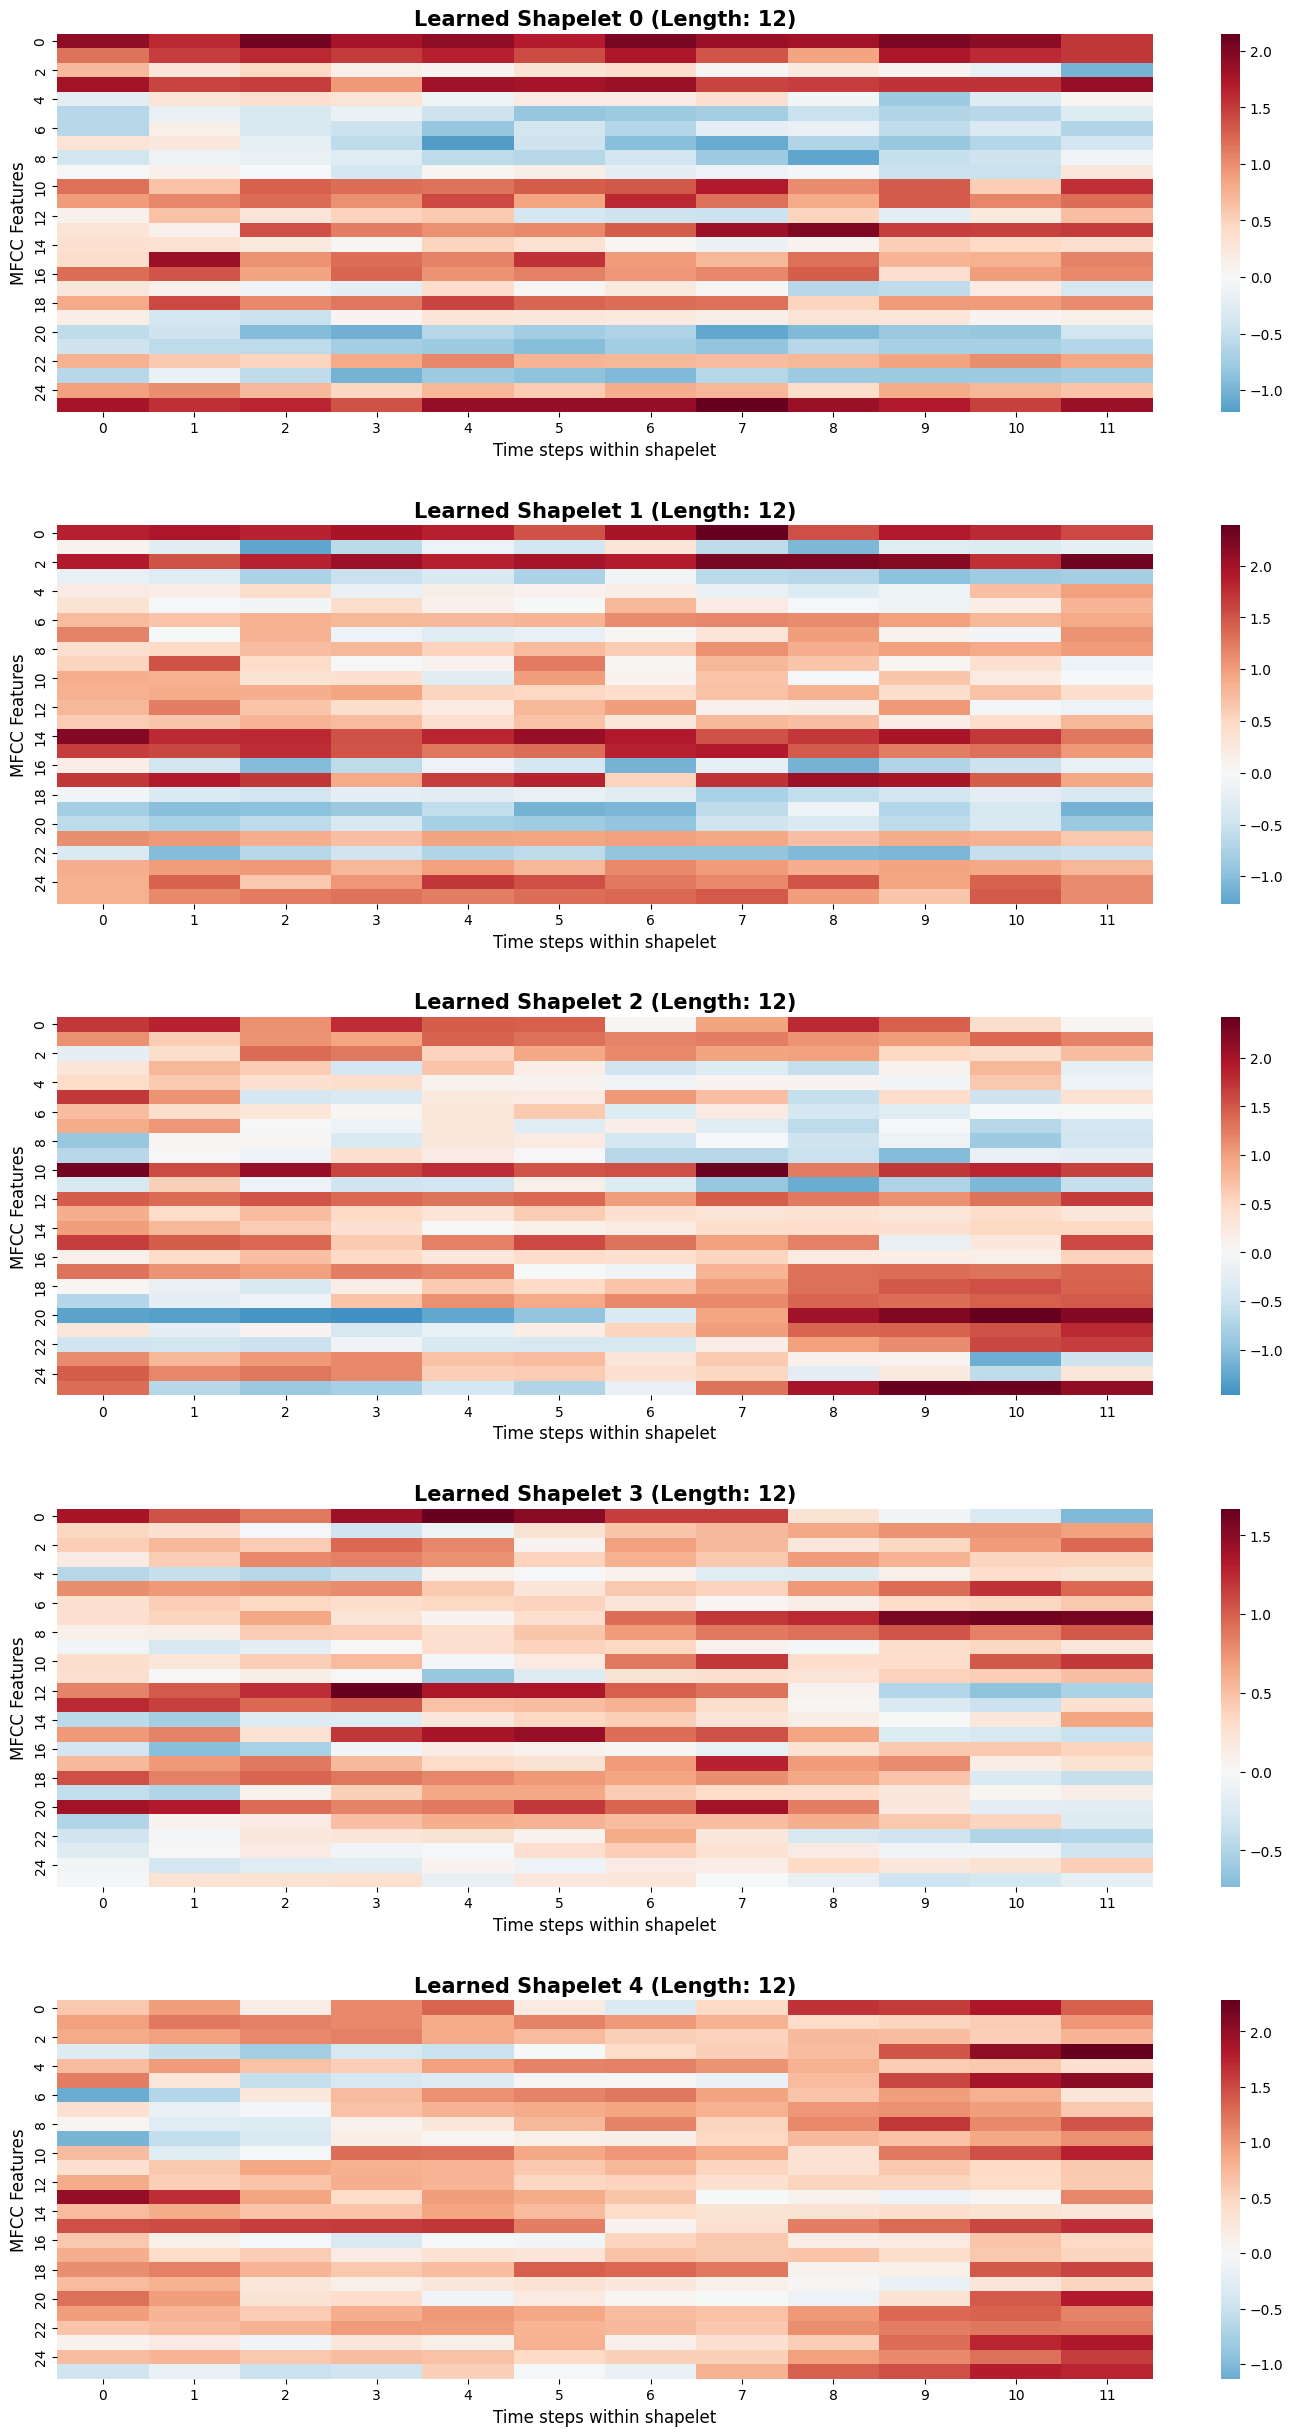

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Access the individual shapelets
shp_list = shp_clf.shapelets_
n_total = len(shp_list)

# 2. Plotting (One per row to make them large and interpretable)
plt.figure(figsize=(15, 5 * n_total))

for i, s in enumerate(shp_list):
    ax = plt.subplot(n_total, 1, i + 1)

    # Transpose (.T) so MFCC features are on the Y-axis and Time is on the X-axis
    sns.heatmap(s.T, cmap='RdBu_r', center=0, ax=ax)

    plt.title(f"Learned Shapelet {i} (Length: {s.shape[0]})", fontsize=15, fontweight='bold')
    plt.ylabel("MFCC Features", fontsize=12)
    plt.xlabel("Time steps within shapelet", fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

In [14]:
# Check which class is encoded as 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_true) # Assuming you used something like this
print(f"Class 0: {le.classes_[0]}")
print(f"Class 1: {le.classes_[1]}")

print("\n--- Corrected Attribution Logic ---")
weights = shp_clf.model_.get_weights()[-2]

for i in range(len(shp_list)):
    w = weights[i][0]
    # Standard Logic: Negative weight favors Class 1, Positive favors Class 0
    if w < 0:
        predicted_artist = le.classes_[1] # The "Positive" Class
    else:
        predicted_artist = le.classes_[0] # The "Negative" Class

    print(f"Shapelet {i}: Predicts {predicted_artist} (Weight: {w:.4f})")

Class 0: 0
Class 1: 1

--- Corrected Attribution Logic ---
Shapelet 0: Predicts 0 (Weight: 0.4288)
Shapelet 1: Predicts 0 (Weight: 0.3450)
Shapelet 2: Predicts 1 (Weight: -0.4252)
Shapelet 3: Predicts 0 (Weight: 0.4774)
Shapelet 4: Predicts 1 (Weight: -0.3291)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step


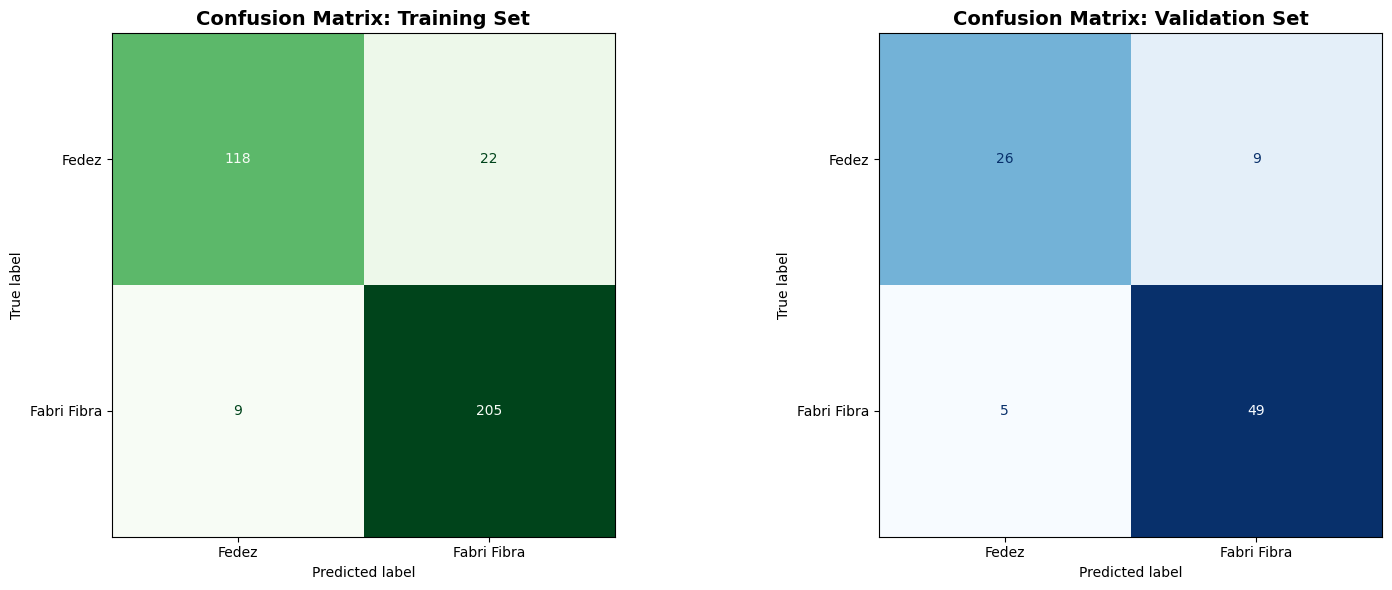

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions for both sets
# Training predictions
y_train_pred_probs = shp_clf.model_.predict(X_train)
y_train_pred = (y_train_pred_probs > 0.5).astype(int).flatten()

# Validation predictions
y_val_pred_probs = shp_clf.model_.predict(X_val)
y_val_pred = (y_val_pred_probs > 0.5).astype(int).flatten()

# 2. Compute Confusion Matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val = confusion_matrix(y_val, y_val_pred)

# 3. Setup Plotting
display_labels = ['Fedez', 'Fabri Fibra']
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Matrix
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels)
disp_train.plot(ax=ax[0], cmap='Greens', values_format='d', colorbar=False)
ax[0].set_title('Confusion Matrix: Training Set', fontsize=14, fontweight='bold')

# Plot Validation Matrix
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=display_labels)
disp_val.plot(ax=ax[1], cmap='Blues', values_format='d', colorbar=False)
ax[1].set_title('Confusion Matrix: Validation Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# 1. Get Distances (How good is the match?) AND Locations (Where is it?)
distances = shp_clf.transform(X_scaled_ls)  # Shape: (n_songs, n_shapelets)
locations = shp_clf.locate(X_scaled_ls)     # Shape: (n_songs, n_shapelets)

# 2. Correct Audio Parameters (Verify these match your extraction!)
sample_rate = 22050
hop_length = 2048
seconds_per_index = hop_length / sample_rate

# 3. Filter for "Real" Matches
shapelet_id = 2  # Let's look at the first shapelet
target_artist_idx = 0

# Calculate a "good match" threshold (e.g., the average distance across dataset)
threshold = np.mean(distances[:, shapelet_id])

print(f"--- Strong Matches for Shapelet {shapelet_id} ---")

count = 0
for i in range(len(X_scaled_ls)):
    # Check Artist AND Match Quality
    dist = distances[i, shapelet_id]

    if y_true[i] == target_artist_idx and dist < threshold:
        count += 1
        start_idx = locations[i, shapelet_id]
        start_sec = start_idx * seconds_per_index
        end_sec = start_sec + (12 * seconds_per_index) # Assuming len 12

        song_name = df_processed.iloc[i]['title']
        print(f"Song: {song_name[:25]:<25} | Time: {start_sec:.1f}s - {end_sec:.1f}s | Quality: {dist:.4f}")

print(f"\nFound {count} strong matches out of {len(X_scaled_ls)} songs.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
--- Strong Matches for Shapelet 2 ---
Song: L’INFANZIA DIFFICILE DI U | Time: 4.0s - 5.1s | Quality: 19.1011
Song: SEXY SHOP                 | Time: 14.4s - 15.5s | Quality: 18.8801
Song: Che cazzo ridi            | Time: 56.7s - 57.8s | Quality: 18.6328
Song: No Game Freestyle         | Time: 17.5s - 18.6s | Quality: 19.0383
Song: PROBLEMI CON TUTTI (GIUDA | Time: 8.5s - 9.6s | Quality: 19.2044
Song: Dai cazzo Federico        | Time: 29.1s - 30.2s | Quality: 19.1208
Song: MEGLIO DEL CINEMA         | Time: 9.9s - 11.1s | Quality: 19.1739
Song: Kim & Kanye               | Time: 8.8s - 9.9s | Quality: 19.0952
Song: STUPIDO STUPIDO           | Time: 3.1s - 4.2s | Quality: 18.4469
Song: Veleno per topic          | Time: 11.8s - 12.9s | Quality: 18.6358
Song: DISCO PARADISE            | Time: 42.8s - 43.9s | Quality: 19.1035
Song: VITTORIA                  | Time: 38.4s - 39.5s | Quality: 18.8082
Song: VECCHIO  

In [18]:
from tensorflow.keras.models import save_model

# Save the internal Keras model
shp_clf.model_.save("fedez_vs_fibra_model_84acc.h5")

# Save the shapelet coordinates specifically (for visualization later)
np.save("learned_shapelets.npy", shp_clf.shapelets_as_time_series_)

print("✅ Model and Shapelets saved safely.")

✅ Model and Shapelets saved safely.


In [17]:
import pickle

# Carica l'oggetto
with open('fedez_fibra_full_model.pkl', 'rb') as f:
    shp_clf = pickle.load(f)

print(f"✅ Modello caricato! Shapelets pronte: {len(shp_clf.shapelets_as_time_series_)}")

# Verifica immediata
# shp_clf.predict(X_val[:2])

/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'loss': 'binary_crossentropy', 'loss_weights': None, 'metrics': [{'module': 'builtins', 'class_name': 'function', 'config': 'binary_accuracy', 'registered_name': 'function'}, {'module': 'builtins', 'class_name': 'function', 'config': 'binary_crossentropy', 'registered_name': 'function'}], 'weighted_metrics': None, 'run_eagerly': False, 'steps_per_execution': 1, 'jit_compile': True}}.

Exception encountered: Could not locate class 'PatchingLayer'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_se

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


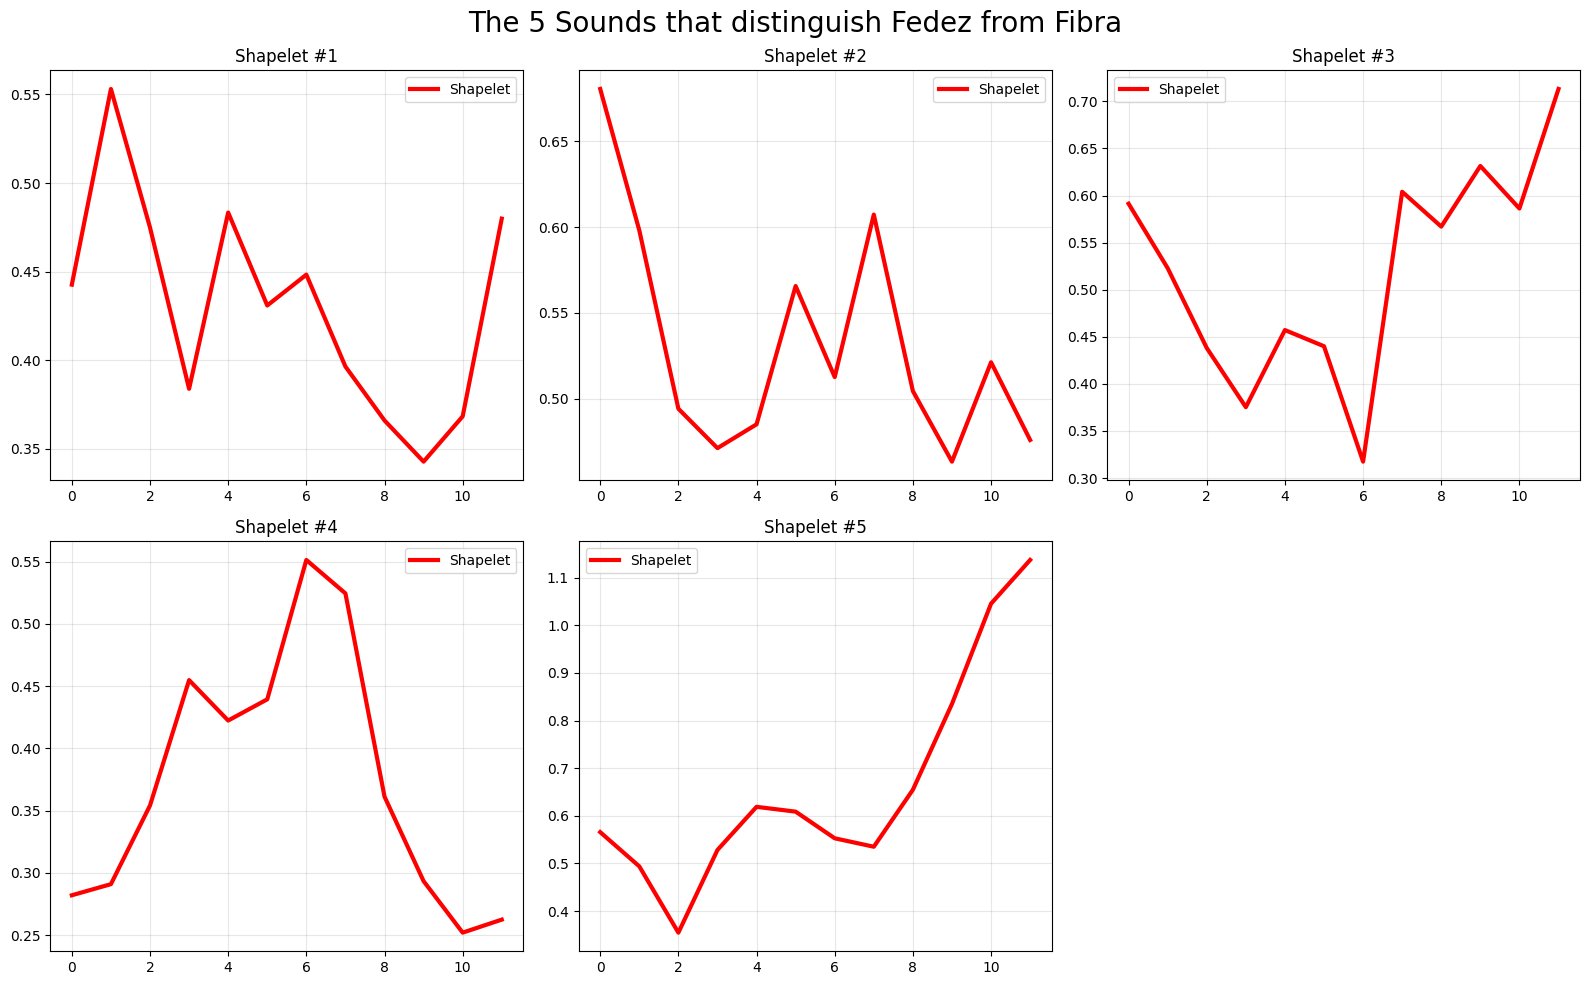

In [17]:

# 1. Get the learned shapelets (The "Prototypical Patterns")
learned_shapelets = shp_clf.shapelets_as_time_series_

# 2. Find where they appear in the dataset
predicted_locations = shp_clf.locate(X_scaled_ls)

# 3. Plot them
plt.figure(figsize=(16, 10))
plt.suptitle(f"The 5 Sounds that distinguish Fedez from Fibra", fontsize=20)

for i in range(len(learned_shapelets)):
    # Find the best matching song for this shapelet
    best_match_idx = np.argmin(shp_clf.transform(X_scaled_ls)[:, i])

    # Get the data
    shapelet = learned_shapelets[i].flatten() # Flatten if 1D plot needed, or keep for heatmap

    # Create Subplot
    ax = plt.subplot(2, 3, i + 1)
    ax.set_title(f"Shapelet #{i+1}")

    # Plot the shapelet (using just the first MFCC coefficient for clarity if it's 2D)
    # If shapelet is (12, 26), we plot the mean envelope to keep it simple
    plt.plot(learned_shapelets[i].mean(axis=1), color='red', linewidth=3, label='Shapelet')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import soundfile as sf

# Settings
output_dir = "shapelet_audio_clips"
os.makedirs(output_dir, exist_ok=True)
hop_length = 2048 # Ensure this matches your extraction!
sr = 22050

print("🎧 Extracting audio for the learned shapelets...")

for i in range(len(learned_shapelets)):
    # 1. Find the song with the strongest match (lowest distance)
    distances = shp_clf.transform(X_scaled_ls)[:, i]
    best_song_idx = np.argmin(distances)

    # 2. Calculate time in seconds
    start_step = predicted_locations[best_song_idx, i]
    start_sec = (start_step * hop_length) / sr
    duration_sec = (12 * hop_length) / sr # 12 is the shapelet length

    # 3. Get the original file path (You need your 'df_processed' here)
    # We assume the order of X matches df_processed
    original_path = df_processed.iloc[best_song_idx]['file_path'] # Adjust column name if needed

    # 4. Load just that snippet
    y_snippet, _ = librosa.load(original_path, sr=sr, offset=start_sec, duration=duration_sec)

    # 5. Save it
    out_name = f"Shapelet_{i+1}_Source_{df_processed.iloc[best_song_idx]['name_artist']}.wav"
    sf.write(os.path.join(output_dir, out_name), y_snippet, sr)

    print(f"   Shapelet {i+1} saved! (Source: {out_name})")

print(f"\n✅ Done! Go to the folder '{output_dir}' and listen to them.")

🎧 Extracting audio for the learned shapelets...
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/tmp/ipython-input-1712855376.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  y_snippet, _ = librosa.load(original_path, sr=sr, offset=start_sec, duration=duration_sec)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'dataset/fedez_fibra/ART07024718 - TR978886.mp3'